# Introduccion

Dataset: (https://www.unb.ca/cic/datasets/ids-2017.html). 

NOTA: descargar la version normal, la ML-Ready tiene caracteristicas eliminadas. Si eso se puede hacer una comparacion de rendimiento entre los dos datasets.

# Pasos (Analisis Exploratorio)
1. Identificar __caracteristicas que puedan producir sesgos__.
2. Identificar __caracteristicas categoricas__. Es necesario darles una codificación numérica, para ello se pueden emplear las estrategias de codificación más habituales (codificación simple, ordinal, One-Hot-Encoding…). Justificar la decisión adoptada.
3. __Grafica de clases y analizar el desbalanceo__. Teniendo en cuenta clasificación binaria como multiclase.
4. __Top 10 caracteristicas mas y menos importantes__. Usando PCA, t-SNE, UMAP...
5. __Matriz de correlación del dataset__
   1. Características derivadas de la misma variable tienen alta correlación.
   2. Ciertas características dependen linealmente del tamaño de paquetes del flujo.
   3. Identificar características correspondientes a estos casos.

## Importar el dataset y dependencias

Crear el venv (Python 3.11) con las dependencias del requirements.txt:
```bash
%python -m venv venv
%pip install -r requirements.txt
```

El dataset descomprimido son unos 1.2Gb, podriamos subirlo a GitHub, pero dejo el .zip y ya lo descomprimis. 

In [1]:
import pandas as pd
import numpy as np

# Leemos un solo dataset para ver como es su estructura, despues leeremos todos
df = pd.read_csv('TrafficLabelling/Wednesday-workingHours.pcap_ISCX.csv')

# Limpiar nombres de columnas (quitar espacios), sino el 'Label' no se reconoce bien
# Y al ser .pcap_ISCX.csv, no podemos abrirlo desde el visor de archivos
df.columns = df.columns.str.strip()

print(f"Shape del dataset: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head())

# Mostramos: Nombre de columnas, Numero de filas, No-nulos, tipo de datos
print(f"\nInformación del dataset:")
print(df.info())

# Generamos estadisticas generales: media, mediana, desviacion estandar, min, max, etc
print(f"\nEstadísticas descriptivas:")
print(df.describe())

# Verificar valores nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Verificar las clases (etiquetas)
if 'Label' in df.columns:
    print(f"\nDistribución de clases:")
    print(df['Label'].value_counts())
    print(f"\nPorcentaje de cada clase:")
    print(df['Label'].value_counts(normalize=True) * 100)

Shape del dataset: (692703, 85)

Primeras filas:
                                  Flow ID      Source IP  Source Port  \
0  192.168.10.14-209.48.71.168-49459-80-6  192.168.10.14        49459   
1  192.168.10.3-192.168.10.17-389-49453-6  192.168.10.17        49453   
2   192.168.10.3-192.168.10.17-88-46124-6  192.168.10.17        46124   
3  192.168.10.3-192.168.10.17-389-49454-6  192.168.10.17        49454   
4   192.168.10.3-192.168.10.17-88-46126-6  192.168.10.17        46126   

  Destination IP  Destination Port  Protocol      Timestamp  Flow Duration  \
0  209.48.71.168                80         6  5/7/2017 8:42          38308   
1   192.168.10.3               389         6  5/7/2017 8:42            479   
2   192.168.10.3                88         6  5/7/2017 8:42           1095   
3   192.168.10.3               389         6  5/7/2017 8:42          15206   
4   192.168.10.3                88         6  5/7/2017 8:42           1092   

   Total Fwd Packets  Total Backward Packet

f:\repos\cyber\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
f:\repos\cyber\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


         Source Port  Destination Port       Protocol  Flow Duration  \
count  692703.000000     692703.000000  692703.000000   6.927030e+05   
mean    42583.995907       5686.869462       9.219523   2.800168e+07   
std     19535.697710      15727.423560       5.009796   4.276680e+07   
min         0.000000          0.000000       0.000000  -1.000000e+00   
25%     36235.000000         53.000000       6.000000   2.010000e+02   
50%     49822.000000         80.000000       6.000000   6.143700e+04   
75%     56892.000000        443.000000      17.000000   8.302437e+07   
max     65535.000000      65487.000000      17.000000   1.200000e+08   

       Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  \
count      692703.000000           692703.000000                 6.927030e+05   
mean            9.556261               10.214079                 5.550930e+02   
std           747.197814              984.204633                 6.163663e+03   
min             1.000000   

Ahora generamos un dataset completo que contenga todos los datasets y aplicamos el analisis exploratorio al conjunto completo de datasets. No estoy seguro de si tendria que se cada dataset por separado para mantener algun tipo de temporalidad. Pero inicialmente vamos a aplicar un analisis y preprocesado al conjunto completo.  

In [2]:
import glob, os
FOLDER_PATH = 'TrafficLabelling'

# Leemos todos los datasets y los concatenamos en un solo DataFrame
all_files = glob.glob(os.path.join(FOLDER_PATH, "*.csv"))
# Teneoms que usar un encoding especifico por el formato CIC-IDS-2017, sino da error al leer los archivos
df = pd.concat((pd.read_csv(f, encoding='latin-1') for f in all_files), ignore_index=True)
df.columns = df.columns.str.strip()  # Limpiar nombres de columnas para simplicar el procesado

# Hay unos caracteres raros , que tenemos que reemplazar por -
df['Label'] = df['Label'].replace({
    'Web Attack  XSS': 'Web Attack - XSS',
    'Web Attack  Sql Injection': 'Web Attack - Sql Injection',
    'Web Attack  Brute Force': 'Web Attack - Brute Force'
})

# El shape final es de 3.119.345 filas X 85 columnas
print(f"Shape del dataset completo: {df.shape}")
print(f"\nClases únicas:")
print(df['Label'].unique())

C:\Users\Pablo\AppData\Local\Temp\ipykernel_45672\3560953865.py:7: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f, encoding='latin-1') for f in all_files), ignore_index=True)


Shape del dataset completo: (3119345, 85)

Clases únicas:
<StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                          nan,                'FTP-Patator',
                'SSH-Patator',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed']
Length: 16, dtype: str


In [3]:
# Para simplicar el analisis posterior guardamos un las cols y la distribucion de clases en un txt
with open('cols_labels.txt', 'w', encoding='utf-8') as f:
    f.write("Columnas del dataset:\n")
    for col in df.columns:
        f.write(f"{col}\n")
    f.write("\n\nDistribucion de clases:\n")
    if 'Label' in df.columns:
        f.write(df['Label'].value_counts().to_string())
        f.write("\n\nPorcentaje de cada clase:\n")
        f.write((df['Label'].value_counts(normalize=True) * 100).to_string())

# Caracteristicas que puedan producir sesgos

La verdad no se que poner aqui porque no se que puede producir sesgos en esto.

# Caracteristicas categoricas

In [4]:
# Identificamos primeros las columnas cuyo tipo de dato es str
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Columnas categoricas: {categorical_cols}")

# El resultado es: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label']
# De estas, la unica que podemos codificar es 'Label', el resto son identificadores/tiempo

Columnas categoricas: Index(['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label'], dtype='str')


C:\Users\Pablo\AppData\Local\Temp\ipykernel_45672\2581468721.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [5]:
# Aplicamos un OneHotEncoder basico, ya que las label son 15
from sklearn.preprocessing import OneHotEncoder

# No creo que necesitemos poner argumentos al encoder ya que es bastante simple el dataset
encoder = OneHotEncoder()
encoded_labels = encoder.fit_transform(df[['Label']])

# Lo pasamos a array para ver las 15 clases
encoded_array = encoded_labels.toarray()
print(f"Shape: {encoded_array.shape}")
# Es normal que salgan todas con la primera clase ya que el dataset esta muy desbalanceado
print(f"Primeras 5 filas:\n{encoded_array[:5]}")

Shape: (3119345, 16)
Primeras 5 filas:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [6]:
# Añadimos las columnas codificadas al DataFrame original
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Label']))
df = pd.concat([df, encoded_df], axis=1)

# Eliminar la columna de label orginal y las columnas de IPs, Flow ID y Timestamp,
#  ya que no aportan informacion util para el analisis y son categoricas no codificables

# Al ser esto el analisis y no el preprocesado, no eliminamos estas columnas (creo=?)
# df = df.drop(columns=['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'], errors='ignore')

# De esta forma nos quedan las 85 columnas originales + 15 columnas codificadas
print(f"Shape del dataset después de limpiar: {df.shape}")
print(f"Columnas numéricas + etiquetas codificadas: {df.shape[1]}")

Shape del dataset después de limpiar: (3119345, 101)
Columnas numéricas + etiquetas codificadas: 101


# Grafica de clases y analizar el desbalanceo

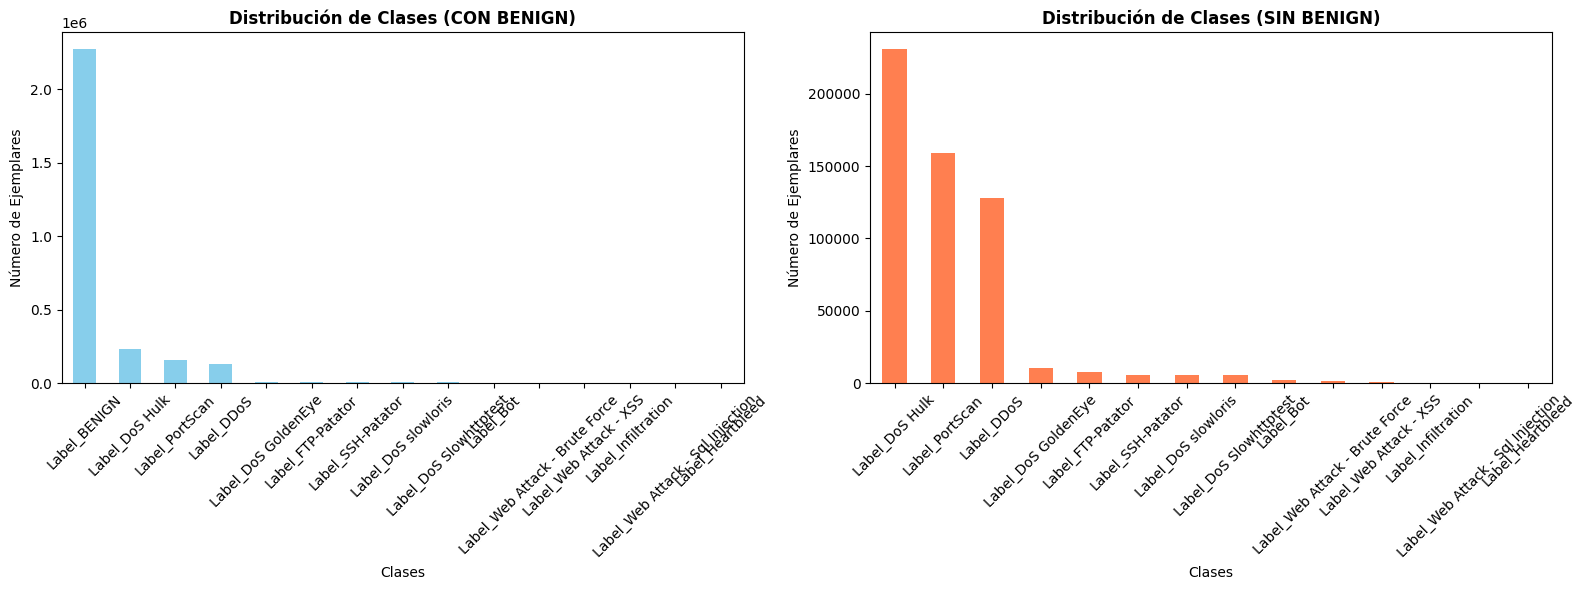

Distribución de clases:
Label_BENIGN                        2273097.0
Label_DoS Hulk                       231073.0
Label_PortScan                       158930.0
Label_DDoS                           128027.0
Label_DoS GoldenEye                   10293.0
Label_FTP-Patator                      7938.0
Label_SSH-Patator                      5897.0
Label_DoS slowloris                    5796.0
Label_DoS Slowhttptest                 5499.0
Label_Bot                              1966.0
Label_Web Attack - Brute Force         1507.0
Label_Web Attack - XSS                  652.0
Label_Infiltration                       36.0
Label_Web Attack - Sql Injection         21.0
Label_Heartbleed                         11.0
dtype: float64

Porcentaje de BENIGN: 80.30%

Distribución sin BENIGN:
Label_DoS Hulk                      231073.0
Label_PortScan                      158930.0
Label_DDoS                          128027.0
Label_DoS GoldenEye                  10293.0
Label_FTP-Patator                  

In [7]:
import matplotlib.pyplot as plt

# Grafica de clases CON BENIGN
class_counts = df[['Label_BENIGN', 'Label_Bot', 'Label_DDoS', 'Label_DoS GoldenEye', 
                   'Label_DoS Hulk', 'Label_DoS Slowhttptest', 'Label_DoS slowloris', 
                   'Label_FTP-Patator', 'Label_Heartbleed', 'Label_Infiltration', 
                   'Label_PortScan', 'Label_SSH-Patator', 'Label_Web Attack - Brute Force', 
                   'Label_Web Attack - Sql Injection', 'Label_Web Attack - XSS']].sum()

# Descendente
class_counts = class_counts.sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CON BENIGN
class_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribución de Clases (CON BENIGN)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Clases')
ax1.set_ylabel('Número de Ejemplares')
ax1.tick_params(axis='x', rotation=45)

# SIN BENIGN
class_counts_sin_benign = class_counts.drop('Label_BENIGN')
class_counts_sin_benign.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Distribución de Clases (SIN BENIGN)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Clases')
ax2.set_ylabel('Número de Ejemplares')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Stats de la distribucion de clases
print("Distribución de clases:")
print(class_counts)
print(f"\nPorcentaje de BENIGN: {(class_counts['Label_BENIGN'] / class_counts.sum() * 100):.2f}%")
print(f"\nDistribución sin BENIGN:")
print(class_counts_sin_benign)
print(f"\nPorcentaje de ataques (sin BENIGN): {(class_counts_sin_benign.sum() / class_counts.sum() * 100):.2f}%")

# Porcentaje de cada clase
print(f"\nPorcentaje de cada clase:")
class_percentages = (class_counts / class_counts.sum() * 100)
for label, percentage in class_percentages.items():
    print(f"{label}: {percentage:.2f}%")

# Top 10 caracteristicas mas y menos importante

Probamos tanto con PCA como con t-SNE y UMAP.

In [8]:
# Hay que realizar una limpieza previa para poder usar PCA y t-SNE
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Separar features y labels
label_cols = [col for col in df.columns if col.startswith('Label_')]
feature_cols = [col for col in df.columns if not col.startswith('Label_')]

X = df[feature_cols].copy()
y = df[label_cols].copy()

# Quedarnos solo con columnas numéricas (evita errores con IP/Flow ID/Timestamp)
X = X.select_dtypes(include=[np.number])

# Limpiar inf/-inf y NaN
X = X.replace([np.inf, -np.inf], np.nan)
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(f"Shape limpio: {X.shape}")

# Usamos un muestreo ya que son 3 millones de filas, con 50.000 tarda 2min aprox
max_samples = 50000
if len(X) > max_samples:
    sample_idx = X.sample(n=max_samples, random_state=42).index
    X = X.loc[sample_idx]
    y = y.loc[sample_idx]
    print(f"Usando muestra de {max_samples} filas para t-SNE")

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Shape limpio: (2827876, 80)
Usando muestra de 50000 filas para t-SNE


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.015s...
[t-SNE] Computed neighbors for 50000 samples in 3.197s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

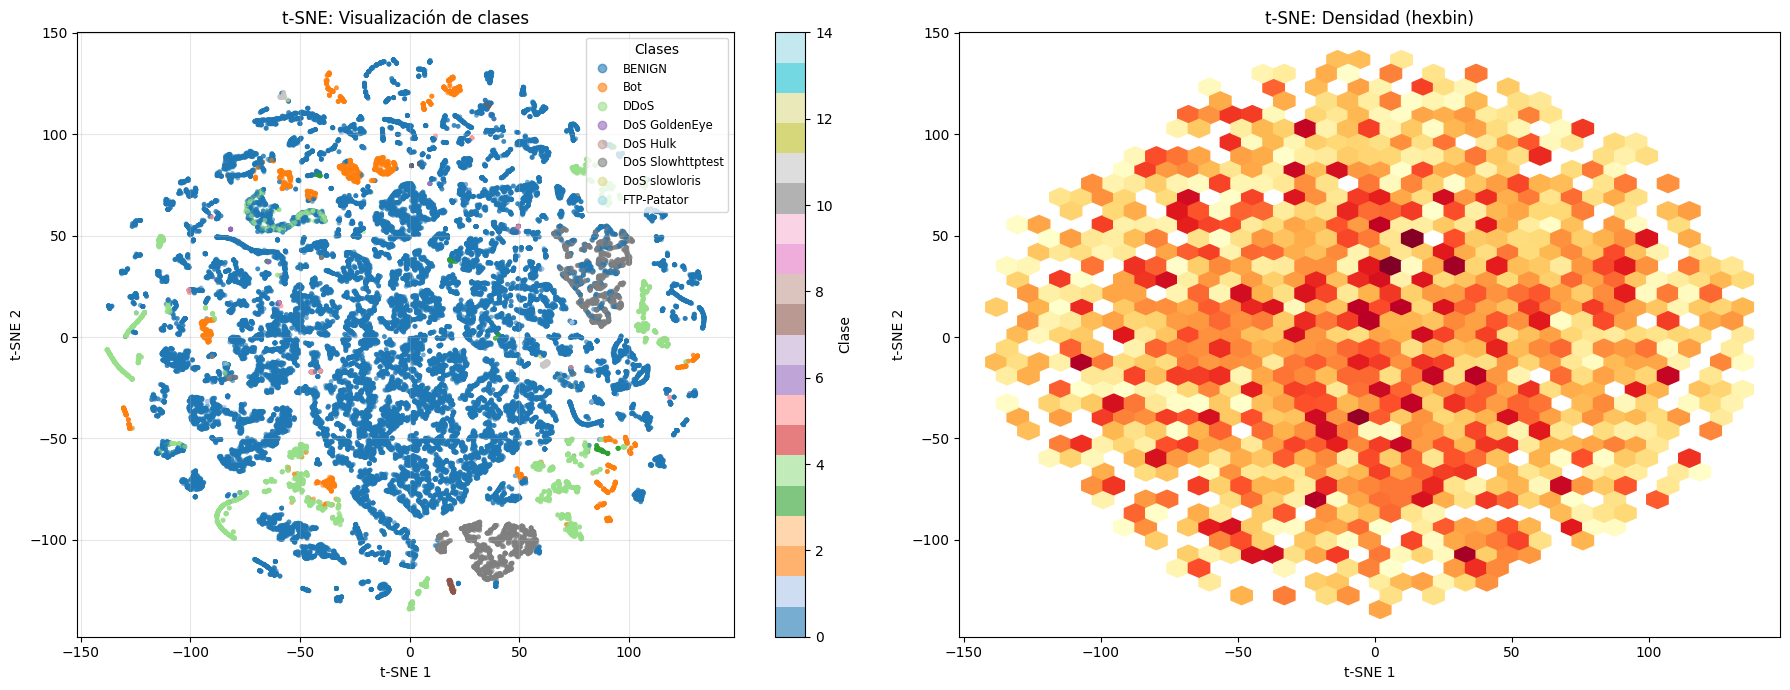


Distribución de clases (muestra usada):
  BENIGN: 40103
  Bot: 48
  DDoS: 2250
  DoS GoldenEye: 147
  DoS Hulk: 4053
  DoS Slowhttptest: 93
  DoS slowloris: 89
  FTP-Patator: 143
  Heartbleed: 0
  Infiltration: 2
  PortScan: 2914
  SSH-Patator: 117
  Web Attack - Brute Force: 29
  Web Attack - Sql Injection: 0
  Web Attack - XSS: 12
  nan: 0


In [9]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    learning_rate='auto',
    init='random',
    verbose=1
)
X_tsne = tsne.fit_transform(X_scaled)

# Clase por fila (one-hot -> índice de clase)
y_class = np.argmax(y.values, axis=1)
class_names = [col.replace('Label_', '') for col in label_cols]

# Gráficas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter = axes[0].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_class, cmap='tab20', alpha=0.6, s=12, edgecolors='none'
)

# Visualizacion basica 
axes[0].set_title('t-SNE: Visualización de clases')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Clase')

# Mapa de calor de densidad (hexbin)
axes[1].hexbin(X_tsne[:, 0], X_tsne[:, 1], gridsize=35, cmap='YlOrRd', mincnt=1)
axes[1].set_title('t-SNE: Densidad (hexbin)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
# No podemos usar la leyenda normal porque esta codificada, asi que la hacemos a mano
handles, _ = scatter.legend_elements()
unique_classes = np.unique(y_class)  # índices presentes en la muestra
legend_labels = [class_names[i] for i in unique_classes]

axes[0].legend(
    handles,
    legend_labels,
    title="Clases",
    loc="upper right",
    fontsize="small"
)
plt.show()

print("\nDistribución de clases (muestra usada):")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {(y_class == i).sum()}")

# Top 10 caracteristicas mas y menos importante y varianza dependiendo del tipo de caracteristica- PCA

Top 10 características MÁS importantes (PCA):
              feature  importance_pca
        Bwd IAT Total        0.094310
          Bwd IAT Max        0.092180
Fwd Packet Length Std        0.088266
             Idle Min        0.088094
          Active Mean        0.087308
          Bwd IAT Std        0.087115
  Average Packet Size        0.086171
Bwd Packet Length Std        0.086060
             Protocol        0.085997
           Active Max        0.085985

Top 10 características MENOS importantes (PCA):
             feature  importance_pca
   Bwd Avg Bulk Rate    2.380574e-32
  Bwd Avg Bytes/Bulk    6.307061e-23
Bwd Avg Packets/Bulk    9.254273e-23
  Fwd Avg Bytes/Bulk    8.311598e-22
   Fwd Avg Bulk Rate    1.475551e-21
Fwd Avg Packets/Bulk    1.325825e-20
       Bwd URG Flags    1.440361e-18
       Bwd PSH Flags    3.139407e-18
      ECE Flag Count    4.169220e-02
      RST Flag Count    4.169220e-02


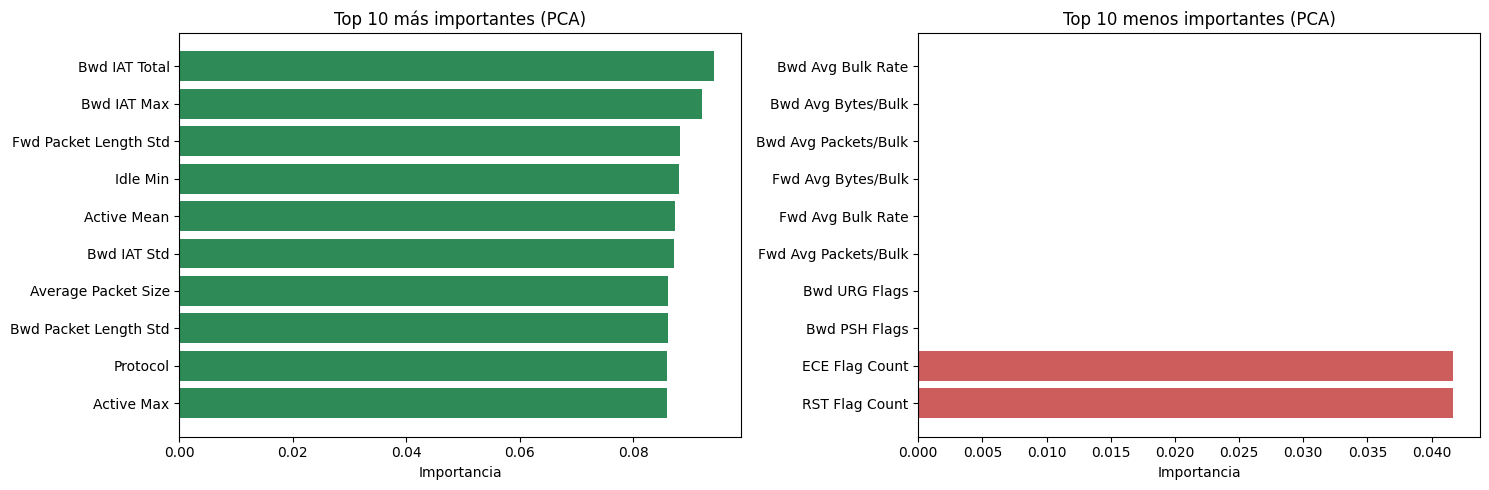

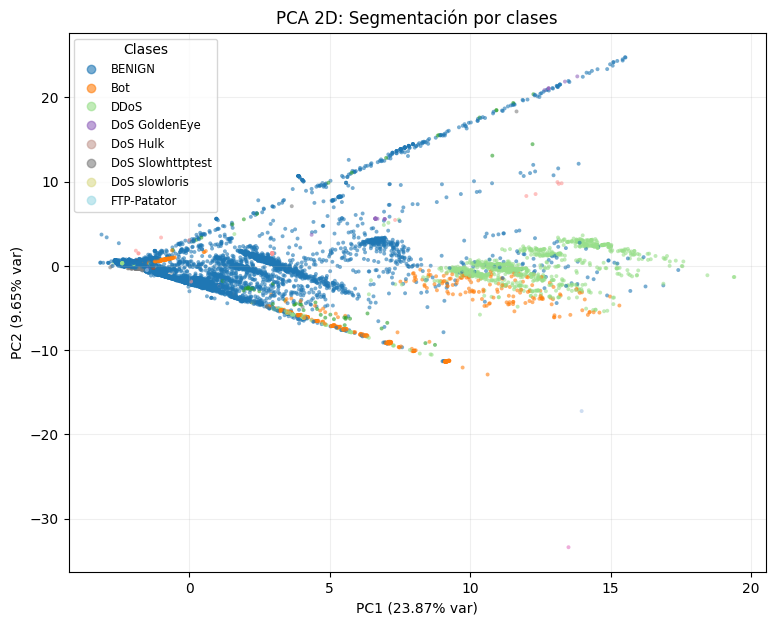

In [10]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit

# Conserva 95% de varianza para el ranking global
pca_full = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

# Importancia por feature:
# importance_i = sum_j |loading_{j,i}| * explained_variance_ratio_j
loadings = pca_full.components_                  # shape: [n_comp, n_features]
weights = pca_full.explained_variance_ratio_     # shape: [n_comp]
importance = (np.abs(loadings).T @ weights)      # shape: [n_features]

imp_df = (
    pd.DataFrame({"feature": X.columns, "importance_pca": importance})
    .sort_values("importance_pca", ascending=False)
    .reset_index(drop=True)
)

top10 = imp_df.head(10)
bottom10 = imp_df.tail(10).sort_values("importance_pca", ascending=True)

print("Top 10 características MÁS importantes (PCA):")
print(top10.to_string(index=False))

print("\nTop 10 características MENOS importantes (PCA):")
print(bottom10.to_string(index=False))

# Plot top/bottom 10
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10["feature"][::-1], top10["importance_pca"][::-1], color="seagreen")
axes[0].set_title("Top 10 más importantes (PCA)")
axes[0].set_xlabel("Importancia")

axes[1].barh(bottom10["feature"][::-1], bottom10["importance_pca"][::-1], color="indianred")
axes[1].set_title("Top 10 menos importantes (PCA)")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

# Submuestra para visualización (rápido)
n_viz = min(20_000, len(X))
if len(X) > n_viz:
    sss_viz = StratifiedShuffleSplit(n_splits=1, train_size=n_viz, random_state=42)
    idx_viz, _ = next(sss_viz.split(X_scaled, y))
    X_viz = X_scaled[idx_viz]
    y_viz = y.iloc[idx_viz]
else:
    X_viz = X_scaled
    y_viz = y

pca_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_2d.fit_transform(X_viz)

# codificación de clase para color
y_cat = pd.Categorical(y_viz)
# y_viz viene de one-hot -> convertir a índice de clase por fila
y_codes = np.argmax(y_viz.values, axis=1)   # longitud = n_muestras
class_names = [c.replace("Label_", "") for c in y_viz.columns]

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=y_codes, cmap="tab20", s=8, alpha=0.6, edgecolors="none"
)
plt.title("PCA 2D: Segmentación por clases")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% var)")
plt.grid(alpha=0.2)

# Leyenda con nombres originales de clase
handles, _ = sc.legend_elements()
present = np.unique(y_codes)
labels = [class_names[i] for i in present]
plt.legend(handles, labels, title="Clases", loc="best", fontsize="small")

plt.show()

# Matriz de Correlacion

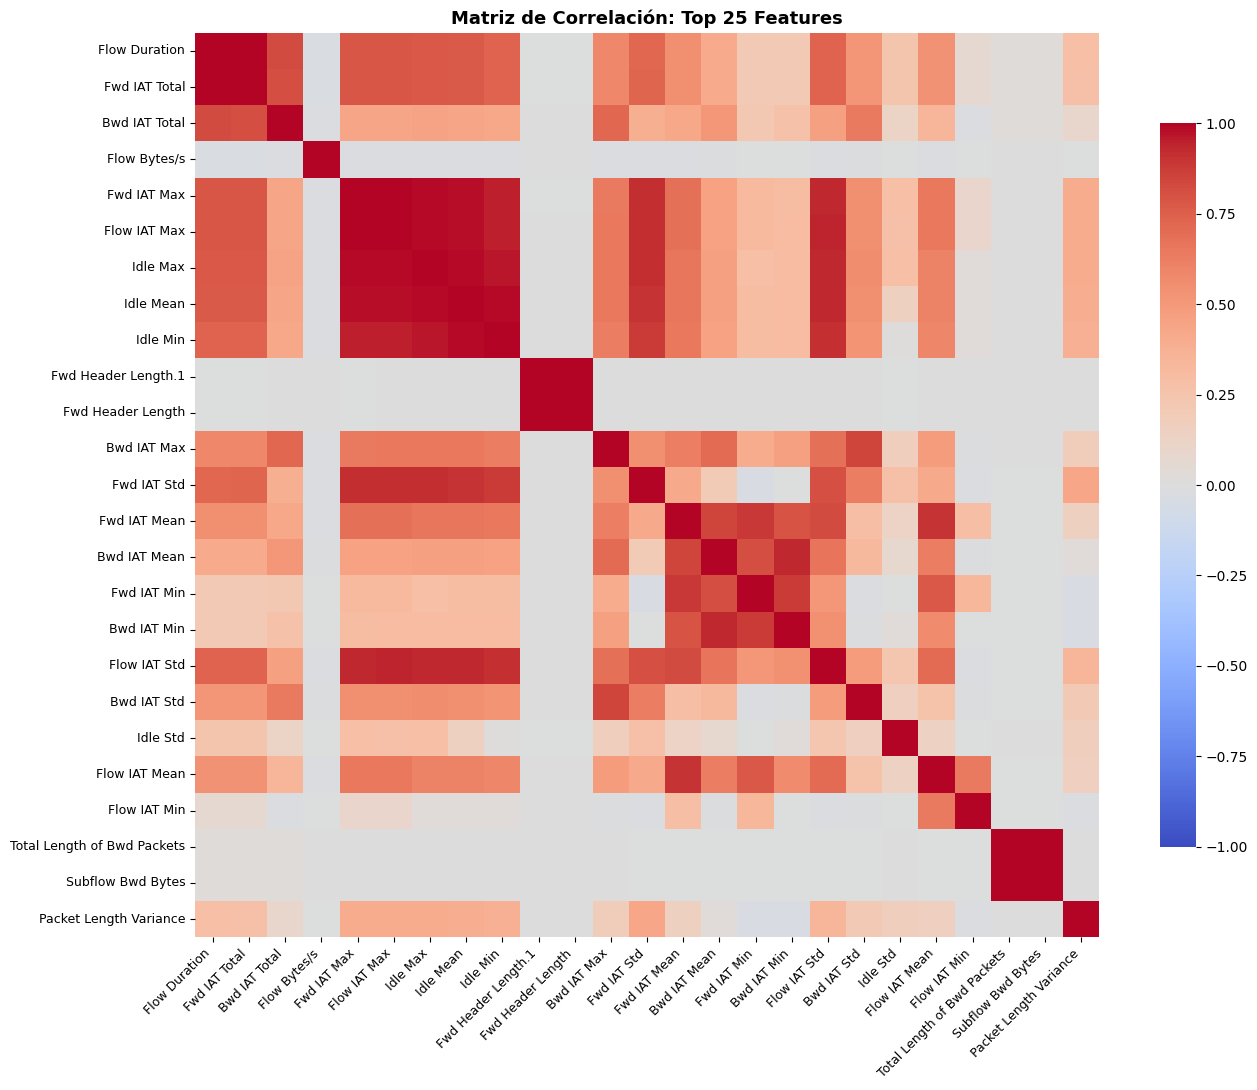

In [12]:
import seaborn as sns

# Preparar datos numéricos
numeric_cols = [col for col in df.columns if col not in ['Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'] 
                and not col.startswith('Label_')]
df_numeric = df[numeric_cols].select_dtypes(include=[np.number])
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).dropna()

# Matriz de correlación de top 25 features (por varianza)
top_features = df_numeric.var().sort_values(ascending=False).head(25).index
corr_matrix = df_numeric[top_features].corr()

# Visualizar
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de Correlación: Top 25 Features", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*80)
print("Características Altamente Correlacionadas (r > 0.90)")
print("="*80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.90:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': round(corr_val, 4)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlación', key=abs, ascending=False)
    print(f"\nEncontrados {len(high_corr_df)} pares altamente correlacionados:")
    for idx, row in high_corr_df.iterrows():
        print(f"  {row['Feature 1']} <-> {row['Feature 2']}: r = {row['Correlación']}")
else:
    print("\nNo se encontraron pares con r > 0.90 en el top 25")

print("\n" + "="*80)
print("Características Relacionadas con Tamaño de Paquetes")
print("="*80)

size_keywords = ['packet', 'bytes', 'length', 'size', 'data', 'payload']
size_related = [col for col in df_numeric.columns if any(kw in col.lower() for kw in size_keywords)]

if size_related:
    print(f"\nCaracterísticas de tamaño encontradas ({len(size_related)}):")
    for col in sorted(size_related):
        print(f"  - {col}")
    
    # Correlaciones entre features de tamaño
    if len(size_related) > 1:
        size_corr = df_numeric[size_related].corr()
        print(f"\nCorrelaciones entre características de tamaño (r > 0.85):")
        for i in range(len(size_corr.columns)):
            for j in range(i+1, len(size_corr.columns)):
                corr_val = size_corr.iloc[i, j]
                if abs(corr_val) > 0.85:
                    print(f"  {size_corr.columns[i]} <-> {size_corr.columns[j]}: r = {round(corr_val, 4)}")
else:
    print("\nNo se encontraron características con palabras clave de tamaño")


Características Altamente Correlacionadas (r > 0.90)

Encontrados 24 pares altamente correlacionados:
  Total Length of Bwd Packets <-> Subflow Bwd Bytes: r = 1.0
  Fwd Header Length.1 <-> Fwd Header Length: r = 1.0
  Flow Duration <-> Fwd IAT Total: r = 0.9986
  Fwd IAT Max <-> Flow IAT Max: r = 0.9981
  Idle Max <-> Idle Mean: r = 0.9904
  Idle Mean <-> Idle Min: r = 0.9902
  Flow IAT Max <-> Idle Max: r = 0.9892
  Fwd IAT Max <-> Idle Max: r = 0.9884
  Flow IAT Max <-> Idle Mean: r = 0.9797
  Fwd IAT Max <-> Idle Mean: r = 0.9781
  Idle Max <-> Idle Min: r = 0.9618
  Flow IAT Max <-> Idle Min: r = 0.9515
  Fwd IAT Max <-> Idle Min: r = 0.9491
  Flow IAT Max <-> Flow IAT Std: r = 0.9382
  Fwd IAT Max <-> Flow IAT Std: r = 0.9362
  Idle Max <-> Flow IAT Std: r = 0.9359
  Bwd IAT Mean <-> Bwd IAT Min: r = 0.9328
  Idle Mean <-> Flow IAT Std: r = 0.9316
  Fwd IAT Max <-> Fwd IAT Std: r = 0.9183
  Flow IAT Max <-> Fwd IAT Std: r = 0.916
  Idle Max <-> Fwd IAT Std: r = 0.9154
  Idle Min 

# Preporcesado
1. __Agrupar valores de caracteristicas__. Si se considera necesario o interesante agrupar por rangos los valores de una categoría. Justificar la decisión adoptada.
2. __Gestionar missing values y duplicados__. (suprimir, imputación simple, imputación guiada, imputación informada…).Justificar la decisión adoptada.
3. __Gestionar outliers__. Detectar si existen y tomar la decisión de qué hacer con ellos aplicando las estrategias más habituales: análisis visual, IQR, Percentiles, Z-score, IsolationForest… Justificar la decisión adoptada.
4. __Escalar/Normalizar datos__. Las estrategias más habituales para aplicar son: estandarización, escalado mínimo-máximo, escalado robusto, escalado absoluto, escalado por la norma… Justificar la decisión adoptada.
5. __Windowing__ si el modelo a entrenar es temporal. 
6. __Seleccion de caracteristicas/Reduccion de dimensionalidad__. (PCA, Random Forest, etc.). Justificar la decisión adoptada.
7. __Split Train/Test/Validation__. Si hay desbalanceo, realizar un split estratificado por clases. Justificar la decisión adoptada.
    1. Se puede realizar undersampling y oversampling (SMOTE, ADASYN, etc.) para balancear el dataset. Justificar la decisión adoptada. Usar tecnicas adicionales de balanceo se evaluara positivamente. 